# Shopping Behavior Analysis

This notebook analyzes customer shopping behavior using pandas and matplotlib. The goal is to explore purchasing trends, seasonal patterns, and customer preferences using data from the shopping dataset.

In [104]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/shopping.csv')

df.head()

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,3475,NaN,Male,Jacket,30.904467,Maine,M,Burnt orange,Fall,4.0,Standard,No,0,Credit Card,NaN
1,3698,21.0,Female,Backpack,31.588259,NaN,L,Turquoise,Winter,2.0,Express,No,1,Credit Card,Monthly
2,2756,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,4.0,Standard,No,0,Credit Card,NaN
3,3340,NaN,Male,Pajamas,33.918834,Nebraska,M,Black,Winter,NaN,Standard,No,2,Credit Card,Bi-Weekly
4,3391,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,NaN,Standard,No,0,Credit Card,NaN


In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3510 non-null   float64
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Purchase Amount (USD)   3900 non-null   float64
 5   Location                3510 non-null   str    
 6   Size                    3900 non-null   str    
 7   Color                   3900 non-null   str    
 8   Season                  3900 non-null   str    
 9   Review Rating           1431 non-null   float64
 10  Shipping Type           3900 non-null   str    
 11  Promo Code Used         3900 non-null   str    
 12  Previous Purchases      3900 non-null   int64  
 13  Payment Method          3900 non-null   str    
 14  Frequency of Purchases  1560 non-null   str    
dty

In [106]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3510.000000,3900.000000,1431.000000,3900.000000
mean,1950.500000,34.256695,38.708329,3.904962,5.841538
std,1125.977353,10.616340,11.504923,1.105952,5.843695
min,1.000000,18.000000,11.392520,1.000000,0.000000
25%,975.750000,26.000000,29.332617,4.000000,1.000000
50%,1950.500000,33.000000,36.953004,4.000000,4.000000
75%,2925.250000,41.000000,48.739596,5.000000,9.000000
max,3900.000000,75.000000,69.567481,5.000000,20.000000


## Question 1:  Does customers with promo codes spend  more than customers who do not use a promo code?

In [107]:
df.groupby('Promo Code Used')['Purchase Amount (USD)'].mean()

Promo Code Used
No     30.172085
Yes    50.023814
Name: Purchase Amount (USD), dtype: float64

## Question 2:  ## Question 2: Which season has the highest total purchase revenue?

In [108]:
df.groupby('Season')['Purchase Amount (USD)'].sum()

Season
Fall      41004.570210
Spring    22829.415359
Summer    36446.813666
Winter    50681.682052
Name: Purchase Amount (USD), dtype: float64

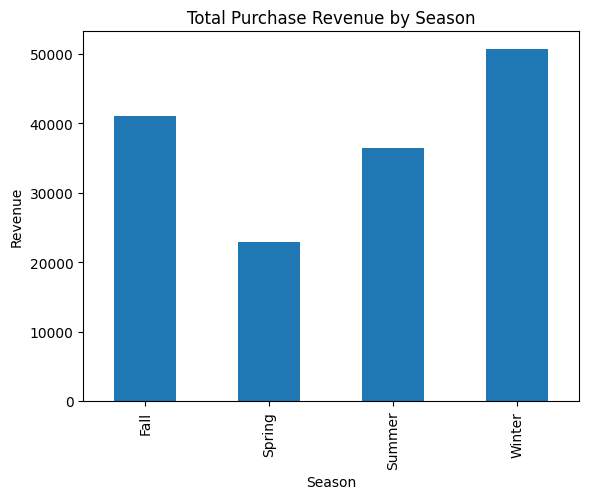

In [109]:
season_sales = df.groupby('Season')['Purchase Amount (USD)'].sum()

season_sales.plot(kind='bar')

plt.title('Total Purchase Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Revenue')

plt.show()

This shows which season generates the highest total revenue. The results indicate that some seasons lead to higher customer spending than others, suggesting seasonal shopping patterns. This analysis shows the total purchase revenue across different seasons. One season clearly generates the highest total spending, indicating that customer purchasing behavior changes depending on the time of year.

## Question 3: What are the top 3 most frequently purchased items in Summer, comparing male vs female customers?

In [110]:
summer_df = df[df['Season'] == 'Summer']


In [111]:

summer_df.head()

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
4,3391,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,NaN,Standard,No,0,Credit Card,NaN
7,3650,29.0,Male,Shorts,23.796439,Minnesota,M,Lavender,Summer,2.0,Express,No,0,Credit Card,NaN
9,2477,39.0,Female,Shorts,32.374104,Colorado,M,Fuchsia,Summer,NaN,Standard,No,3,Credit Card,Bi-Weekly
12,3341,27.0,Female,Handbag,29.430620,Virginia,XL,Black,Summer,NaN,Standard,No,2,Credit Card,Weekly
13,1722,32.0,Female,Handbag,34.151352,Delaware,S,White,Summer,4.0,Standard,No,11,Credit Card,Monthly


In [112]:
summer_df.groupby(['Gender', 'Item Purchased']).size().groupby(level=0, group_keys=False).nlargest(3)

Gender      Item Purchased
Female      Shorts            98
            Running Shoes     91
            T-shirt           83
Male        Sunglasses        85
            Dress             78
            Shorts            78
Non-binary  Running Shoes      3
            Handbag            2
            Dress              1
dtype: int64

This analysis compares the top three most frequently purchased items during summer for male and female customers. The results show that purchasing preferences differ between genders, indicating that customer demographics influence which products are most popular during the summer season.

## Question 4: How does payment method affect total purchase amount, and does this relationship differ by gender?

In [113]:
pd.pivot_table(
    df,
    values='Purchase Amount (USD)',
    index='Payment Method',
    columns='Gender',
    aggfunc='sum'
)

Gender,Female,Male,Non-binary
Payment Method,,,
Bank Transfer,292.423726,177.546703,NaN
Cash,187.364842,184.385006,NaN
Credit Card,26769.912597,26901.032811,379.819967
Debit Card,25224.597032,24816.908446,432.492604
PayPal,11031.540007,12043.717765,174.035730
Venmo,10114.871879,11908.695075,323.137098


In [114]:
pd.pivot_table(
    df,
    values='Purchase Amount (USD)',
    index='Payment Method',
    columns='Gender',
    aggfunc='mean'
)

Gender,Female,Male,Non-binary
Payment Method,,,
Bank Transfer,48.737288,35.509341,NaN
Cash,37.472968,36.877001,NaN
Credit Card,39.023196,38.266050,34.529088
Debit Card,39.351945,38.297698,39.317509
PayPal,38.571818,38.850702,43.508932
Venmo,37.462488,39.695650,35.904122


This analysis shows how payment method influences total purchase amount and whether spending patterns differ by gender. The results indicate that certain payment methods are associated with higher spending, and there are differences between male and female customers in how much they spend depending on payment type.

## Questions ADD--What are the most popular colors by season?

In [115]:
df.groupby('Season')['Color'].value_counts().groupby(level=0).head(1)

Season  Color    
Fall    Brown        117
Spring  Baby blue     83
Summer  Lavender     120
Winter  Black        155
Name: count, dtype: int64

This shows the most popular color in each season. The results suggest that people tend to prefer different colors depending on the time of year, which points to seasonal shopping patterns.

## Add Question 2: What is the most popular clothing item by season?

In [116]:
df.groupby('Season')['Item Purchased'].value_counts().groupby(level=0).head(1)

Season  Item Purchased
Fall    Socks              87
Spring  Running Shoes     106
Summer  Shorts            177
Winter  Leggings          157
Name: count, dtype: int64

## This data shows  most popular items purchased by the four different seasons.  These results show how customer shopping preferences change depending on the time of the year

## Add- Question3--What is the effect of promo codes on the dollar amount of purchases?

In [117]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Shipping Type', 'Promo Code Used',
       'Previous Purchases', 'Payment Method', 'Frequency of Purchases'],
      dtype='str')

In [118]:
df.groupby('Promo Code Used')['Purchase Amount (USD)'].mean()

Promo Code Used
No     30.172085
Yes    50.023814
Name: Purchase Amount (USD), dtype: float64

This analysis compares the average purchase amount between customers who used promo codes and those who did not. The results show that customers who used promo codes spent more on average, suggesting that promo codes may be associated with higher spending behavior.

## ADD Question 4-When do users leave a review?

In [120]:
df['Review Rating'].value_counts().sort_index()
df.groupby('Season')['Review Rating'].mean()

Season
Fall      3.813953
Spring    3.892683
Summer    4.005882
Winter    3.911824
Name: Review Rating, dtype: float64

This analysis examines how review ratings vary across different conditions in the dataset. The results help identify patterns in when customers tend to leave higher or lower ratings, showing how customer feedback may change based on shopping behavior.

### BASED OFF OF QUESTION 3- IM GOING TO ADD ANOTHER CHART =AVG SPENDING --PROMO CODE USERS

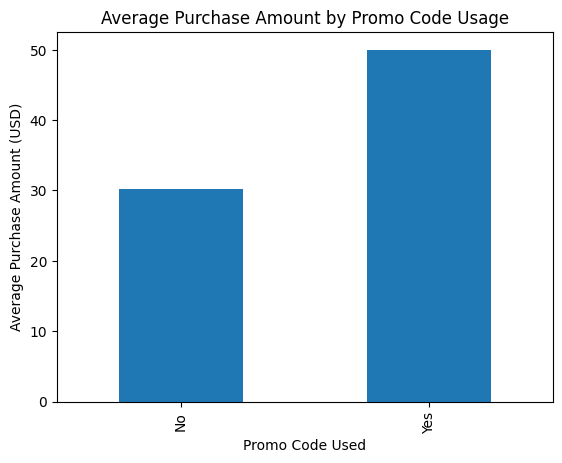

In [122]:
df.groupby('Promo Code Used')['Purchase Amount (USD)'].mean().plot(kind='bar')
plt.title('Average Purchase Amount by Promo Code Usage')
plt.xlabel('Promo Code Used')
plt.ylabel('Average Purchase Amount (USD)')
plt.show()